# **Model: Random Forest**

In [1]:
from google.colab import files
uploaded = files.upload()

Saving CIC-IDS2017.zip to CIC-IDS2017.zip


**1. Imports & configuration**

In [2]:
import os
import glob
import time
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.preprocessing import LabelEncoder

RANDOM_STATE = 42

print("Setup complete")

Setup complete


**2. Extracting Zip**

In [3]:
!find /content -maxdepth 3 -type f | head -100

/content/.config/.last_survey_prompt.yaml
/content/.config/.last_opt_in_prompt.yaml
/content/.config/configurations/config_default
/content/.config/.last_update_check.json
/content/.config/gce
/content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
/content/.config/default_configs.db
/content/.config/config_sentinel
/content/.config/active_config
/content/CIC-IDS2017.zip
/content/sample_data/README.md
/content/sample_data/anscombe.json
/content/sample_data/mnist_test.csv
/content/sample_data/california_housing_test.csv
/content/sample_data/california_housing_train.csv
/content/sample_data/mnist_train_small.csv


In [4]:
!mkdir -p /content/CIC-IDS2017
!unzip -q "/content/CIC-IDS2017.zip" -d "/content/CIC-IDS2017"

print("Dataset extracted successfully")

Dataset extracted successfully


In [5]:
import glob

parquet_files = glob.glob("/content/CIC-IDS2017/**/*.parquet", recursive=True)

print(f"Found {len(parquet_files)} Parquet files")

for file in parquet_files:
    print(file)

Found 8 Parquet files
/content/CIC-IDS2017/DoS-Wednesday-no-metadata.parquet
/content/CIC-IDS2017/Portscan-Friday-no-metadata.parquet
/content/CIC-IDS2017/Benign-Monday-no-metadata.parquet
/content/CIC-IDS2017/DDoS-Friday-no-metadata.parquet
/content/CIC-IDS2017/Infiltration-Thursday-no-metadata.parquet
/content/CIC-IDS2017/Bruteforce-Tuesday-no-metadata.parquet
/content/CIC-IDS2017/Botnet-Friday-no-metadata.parquet
/content/CIC-IDS2017/WebAttacks-Thursday-no-metadata.parquet


**3. Loading files**

In [6]:
import os
import pandas as pd

dataframes = []

for file in parquet_files:
    print(f"Loading: {os.path.basename(file)}")

    temp = pd.read_parquet(file)
    print(f"  Shape: {temp.shape}")

    dataframes.append(temp)

df = pd.concat(dataframes, ignore_index=True)
del dataframes

print("\n------------------------")
print("Combined dataset")
print("------------------------")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Loading: DoS-Wednesday-no-metadata.parquet
  Shape: (584991, 78)
Loading: Portscan-Friday-no-metadata.parquet
  Shape: (119522, 78)
Loading: Benign-Monday-no-metadata.parquet
  Shape: (458831, 78)
Loading: DDoS-Friday-no-metadata.parquet
  Shape: (221264, 78)
Loading: Infiltration-Thursday-no-metadata.parquet
  Shape: (207630, 78)
Loading: Bruteforce-Tuesday-no-metadata.parquet
  Shape: (389714, 78)
Loading: Botnet-Friday-no-metadata.parquet
  Shape: (176038, 78)
Loading: WebAttacks-Thursday-no-metadata.parquet
  Shape: (155820, 78)

------------------------
Combined dataset
------------------------
Rows: 2,313,810
Columns: 78


**4. Inspecting CIC-IDS2017**

In [7]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Down/Up Ra

In [8]:
print(df["Label"].value_counts())

Label
Benign                        1977318
DoS Hulk                       172846
DDoS                           128014
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
PortScan                         1956
Web Attack � Brute Force         1470
Bot                              1437
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [9]:
label_distribution = df["Label"].value_counts(normalize=True) * 100

print(label_distribution)

Label
Benign                        85.457233
DoS Hulk                       7.470190
DDoS                           5.532606
DoS GoldenEye                  0.444548
FTP-Patator                    0.256330
DoS slowloris                  0.232733
DoS Slowhttptest               0.225948
SSH-Patator                    0.139121
PortScan                       0.084536
Web Attack � Brute Force       0.063532
Bot                            0.062105
Web Attack � XSS               0.028179
Infiltration                   0.001556
Web Attack � Sql Injection     0.000908
Heartbleed                     0.000475
Name: proportion, dtype: float64


**5. Data Cleaning**

In [10]:
# Remove duplicate rows
print("Before removing duplicates:", df.shape)

df = df.drop_duplicates().copy()

print("After removing duplicates:", df.shape)
print("Duplicates removed:", 2313810 - len(df))

Before removing duplicates: (2313810, 78)
After removing duplicates: (2231806, 78)
Duplicates removed: 82004


In [11]:
# Replace infinity values with NaN
df = df.replace([np.inf, -np.inf], np.nan)

missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Columns containing missing/invalid values:")
print(missing)

Columns containing missing/invalid values:
Series([], dtype: int64)


In [12]:
# Remove rows containing invalid/missing values
before = len(df)

df = df.dropna().copy()

print("Rows removed:", before - len(df))
print("Final clean shape:", df.shape)

Rows removed: 0
Final clean shape: (2231806, 78)


**6. Create Binary Target**

In [13]:
df["Label"] = df["Label"].astype(str).str.strip()

df["Target"] = np.where(
    df["Label"].str.upper() == "BENIGN",
    0,
    1
)

print("Binary class distribution:")
print(df["Target"].value_counts())

print("\nPercentages:")
print(df["Target"].value_counts(normalize=True) * 100)

Binary class distribution:
Target
0    1895314
1     336492
Name: count, dtype: int64

Percentages:
Target
0    84.922883
1    15.077117
Name: proportion, dtype: float64


**7. Check Features**

In [14]:
X = df.drop(columns=["Label", "Target"])
y = df["Target"]

print("Number of features:", X.shape[1])

non_numeric = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Non-numeric features:")
print(non_numeric)

Number of features: 77
Non-numeric features:
[]


**8. Train/Test Split**

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

print("\nTraining distribution:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting distribution:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True) * 100)

Training set: (1785444, 77)
Testing set : (446362, 77)

Training distribution:
Target
0    1516251
1     269193
Name: count, dtype: int64
Target
0    84.92291
1    15.07709
Name: proportion, dtype: float64

Testing distribution:
Target
0    379063
1     67299
Name: count, dtype: int64
Target
0    84.922776
1    15.077224
Name: proportion, dtype: float64


In [16]:
import gc

del df
gc.collect()

print("Unused dataframe released from memory.")

Unused dataframe released from memory.


**9. Train Random Forest v1**

In [17]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced"
)

start_time = time.time()

rf_model.fit(X_train, y_train)

training_time = time.time() - start_time

print("Random Forest training complete.")
print(f"Training time: {training_time:.2f} seconds")

Random Forest training complete.
Training time: 805.28 seconds


**10. Evaluate Random Forest**

In [18]:
# Make predictions
start_time = time.time()

y_pred = rf_model.predict(X_test)

prediction_time = time.time() - start_time

print(f"Prediction time: {prediction_time:.2f} seconds")

Prediction time: 8.73 seconds


In [19]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=== Sentinel Random Forest v1 ===")
print(f"Accuracy : {accuracy:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall   : {recall:.6f}")
print(f"F1 Score : {f1:.6f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["BENIGN", "ATTACK"],
        digits=6
    )
)

=== Sentinel Random Forest v1 ===
Accuracy : 0.998862
Precision: 0.997334
Recall   : 0.995111
F1 Score : 0.996222

Classification Report:
              precision    recall  f1-score   support

      BENIGN   0.999132  0.999528  0.999330    379063
      ATTACK   0.997334  0.995111  0.996222     67299

    accuracy                       0.998862    446362
   macro avg   0.998233  0.997320  0.997776    446362
weighted avg   0.998861  0.998862  0.998861    446362



**11. Confusion Matrix**

In [20]:
cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

false_positive_rate = fp / (fp + tn)
false_negative_rate = fn / (fn + tp)

print(f"\nFalse Positive Rate: {false_positive_rate:.6f}")
print(f"False Negative Rate: {false_negative_rate:.6f}")

True Negatives : 378884
False Positives: 179
False Negatives: 329
True Positives : 66970

False Positive Rate: 0.000472
False Negative Rate: 0.004889


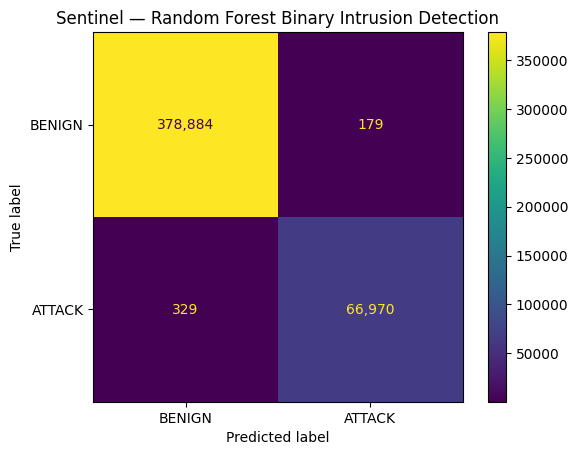

In [21]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["BENIGN", "ATTACK"]
)

disp.plot(values_format=",")
plt.title("Sentinel — Random Forest Binary Intrusion Detection")
plt.show()

**12. Inspection**

In [22]:
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

display(importance_df.head(20))

,Feature,Importance
10,Bwd Packet Length Max,0.066735
12,Bwd Packet Length Mean,0.065901
54,Avg Bwd Segment Size,0.065597
42,Packet Length Variance,0.060075
41,Packet Length Std,0.059864
13,Bwd Packet Length Std,0.059009
52,Avg Packet Size,0.048701
5,Bwd Packets Length Total,0.038001
37,Bwd Packets/s,0.036988
11,Bwd Packet Length Min,0.036011


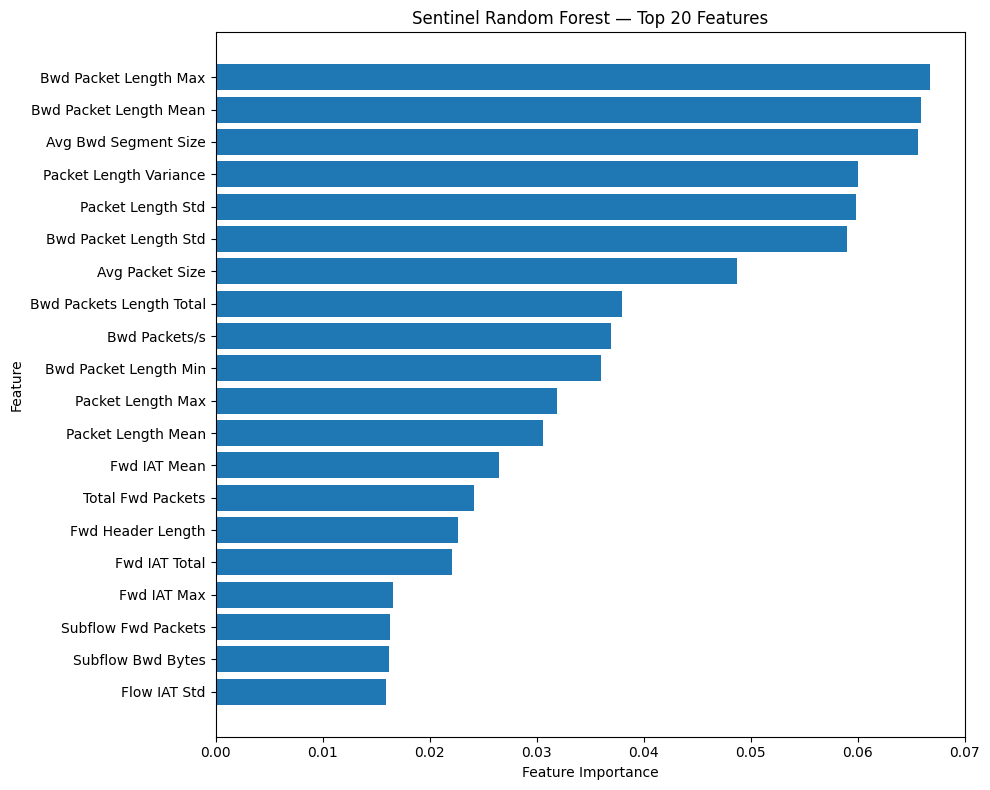

In [23]:
top_features = importance_df.head(20).sort_values("Importance")

plt.figure(figsize=(10, 8))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Sentinel Random Forest — Top 20 Features")
plt.tight_layout()
plt.show()

**13. Saving Results**

In [24]:
import joblib

joblib.dump(
    rf_model,
    "/content/sentinel_random_forest_binary_v1.joblib"
)

joblib.dump(
    X_train.columns.tolist(),
    "/content/sentinel_feature_columns_v1.joblib"
)

print("Saved successfully")

Saved successfully


In [25]:
from google.colab import files

files.download("/content/sentinel_random_forest_binary_v1.joblib")
files.download("/content/sentinel_feature_columns_v1.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>